# Oil Well Location Optimization: Selecting the Most Profitable Region

**Project overview**

An oil company needs to decide **in which region to drill new wells** in order to maximize profit while controlling financial risk.

The dataset contains samples from three potential regions. For each region we have:
- geological features of the locations
- estimated oil reserves (target)
- economic constraints: fixed budget, cost per well and revenue per unit of product

The goal is not just to build an accurate predictive model, but to **support an investment decision**:
- estimate the expected profit for each region
- account for uncertainty in model predictions
- evaluate financial risk using bootstrap simulation
- select the region that provides the **highest expected profit with acceptable risk**


**Business objective**

The main business question:

> **Which region should the company choose for drilling to maximize expected profit, given the budget and risk constraints?**

The result of this project can be used as an analytical justification for capital allocation between regions.


**Project steps**

1. Data loading and quality checks  
2. Exploratory data analysis (EDA) by region  
3. Model training to predict oil reserves  
4. Profit calculation and economic evaluation  
5. Risk assessment using bootstrap  
6. Final recommendation on region selection

## Data preparations & EDA

### Data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

In [3]:
#Key business parameters

N_WELLS = 500          # number of wells to be explored in each region
N_SELECTED = 200       # number of top wells to be selected for development
BUDGET = 10_000_000_000  # total budget for drilling (RUB)
REVENUE_PER_UNIT = 450_000  # revenue per unit of product (RUB)
MAX_RISK = 0.025       # maximum acceptable probability of loss
N_BOOTSTRAP = 1000

We work with three regions, each represented by a separate dataset.  
For every potential well, geological features and the target product volume are provided.

In [4]:
region_0 = pd.read_csv("data/geo_data_0.csv")
region_1 = pd.read_csv("data/geo_data_1.csv")
region_2 = pd.read_csv("data/geo_data_2.csv")

for i, df in enumerate([region_0, region_1, region_2]):
    print(f"\nRegion {i}")
    display(df.head())
    print(df.info())


Region 0


,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None

Region 1


,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None

Region 2


,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None


### Duplicate check

In [5]:
regions = {
    0: region_0,
    1: region_1,
    2: region_2
}

In [6]:
def duplicate_report(regions):
    report = []

    for region_id, df in regions.items():
        report.append({
            "region": region_id,
            "full_row_duplicates": df.duplicated().sum(),
            "duplicates_without_id": df.duplicated(subset=df.columns[1:]).sum()
        })

    return pd.DataFrame(report)

duplicate_report(regions)

,region,full_row_duplicates,duplicates_without_id
0,0,0,0
1,1,0,0
2,2,0,0


### Exploratory data analysis (EDA)

The goal of EDA in this project is not to deeply study the statistical distributions, but to understand whether the data is suitable for predictive modelling and how features relate to the target value (product volume).

In [7]:
# Columns for analysis
num_cols = ['f0', 'f1', 'f2', 'product']

# Show descriptive statistics
for i, df in regions.items():
    print(f"\nRegion {i} — summary statistics:")
    display(df[num_cols].describe())


Region 0 — summary statistics:


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347



Region 1 — summary statistics:


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408



Region 2 — summary statistics:


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


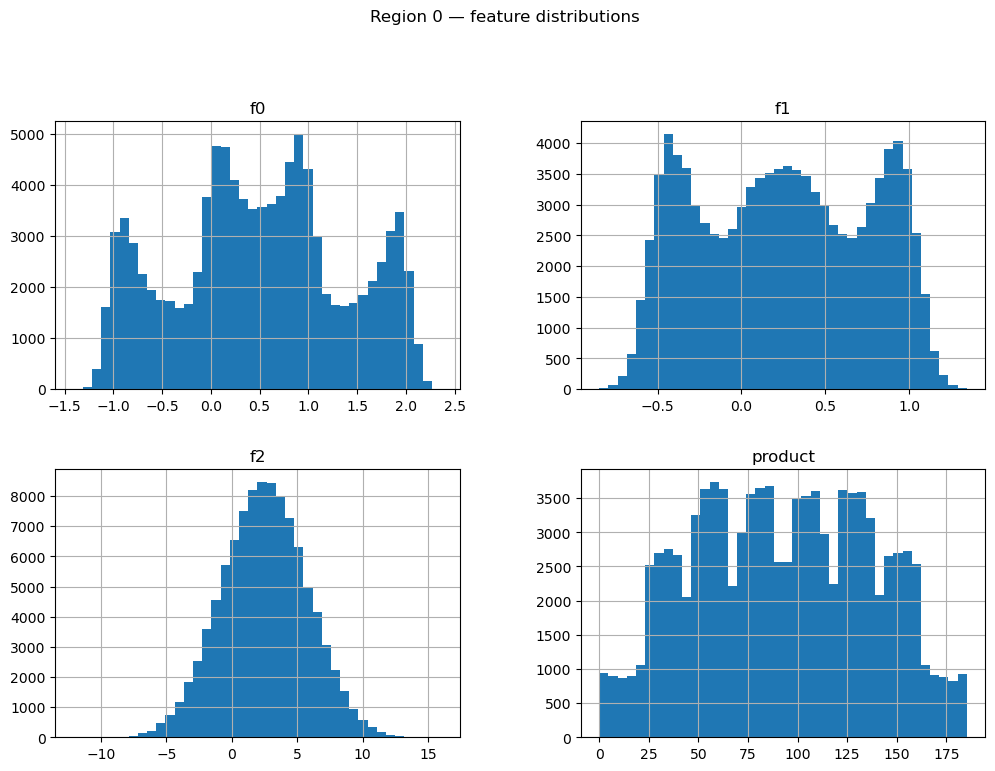

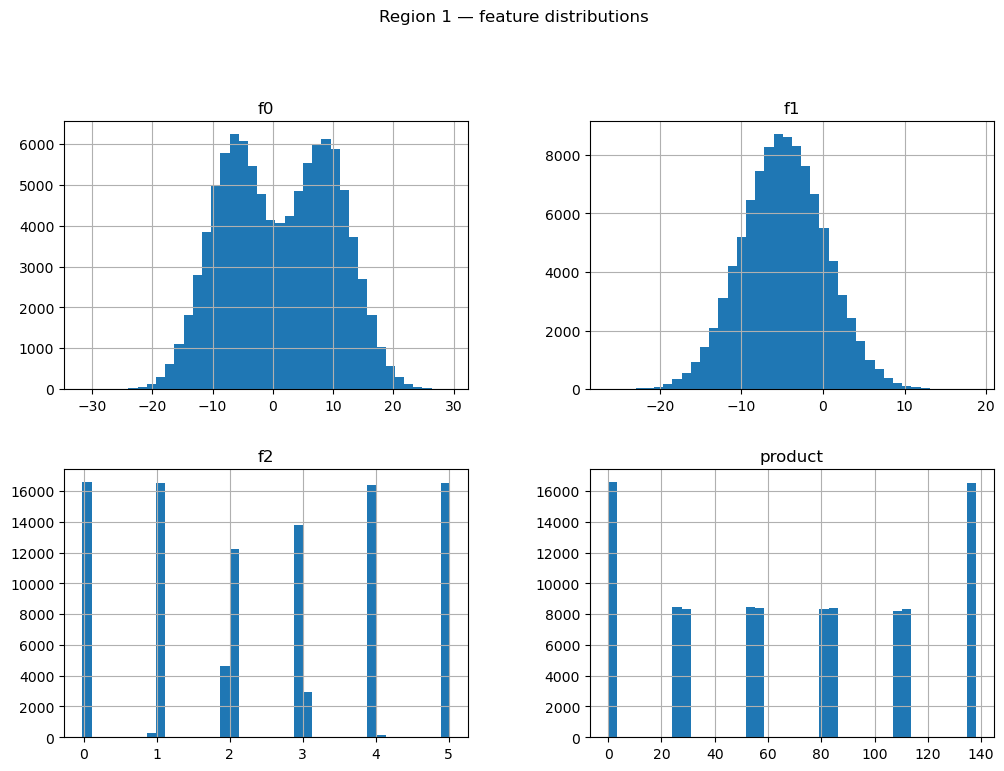

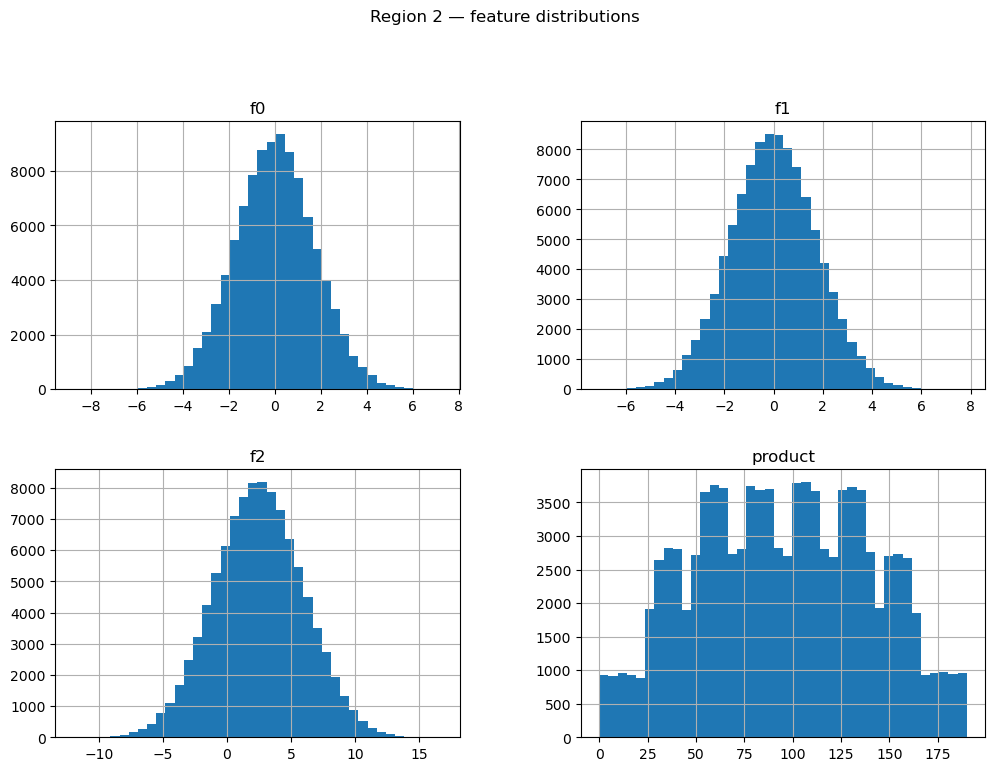

In [8]:
for i, df in regions.items():
    df[num_cols].hist(bins=40, figsize=(12, 8))
    plt.suptitle(f"Region {i} — feature distributions", y=1.02)
    plt.show()

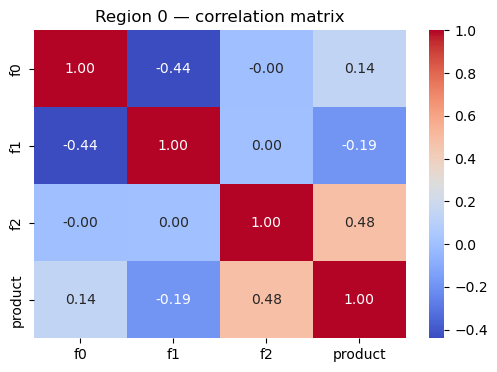

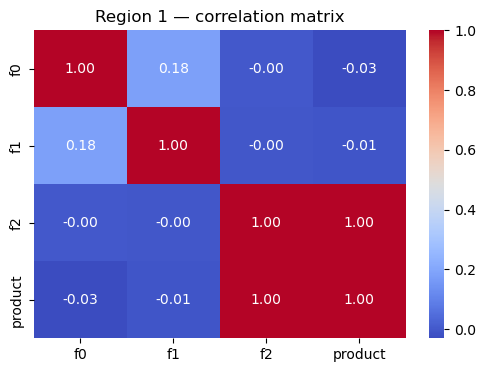

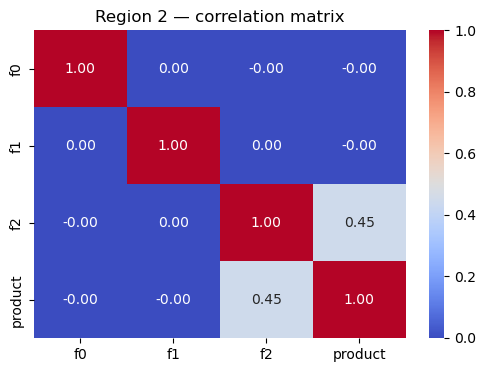

In [9]:
for i, df in regions.items():
    corr = df[num_cols].corr()
    plt.figure(figsize=(6, 4))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(f"Region {i} — correlation matrix")
    plt.show()

- Region 1 shows the clearest linear patterns and the strongest correlation between feature `f2` and product volume.  
  → The model is expected to perform best in this region.

- Region 0 has moderate predictive structure.  
  → Model quality will be acceptable but less stable.

- Region 2 contains more noise and weaker correlations.  
  → Predictions will be less reliable, increasing financial uncertainty.

These differences will directly affect profit estimates during bootstrap simulation and ultimately influence the region selection decision.

## Model Training and Validation

In [10]:
results = {}
feature_cols = ['f0', 'f1', 'f2']

for region_id, df in regions.items():
    print(f"\nRegion {region_id}")

    # Features and target
    X = df[feature_cols]
    y = df['product']

    # Train/validation split
    X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train[feature_cols])
    X_valid_scaled = scaler.transform(X_valid[feature_cols])

    # Model
    model_lr  = LinearRegression()
    model_lr.fit(X_train_scaled, y_train)

    # Predictions
    predictions = model_lr.predict(X_valid_scaled)
    mse = mean_squared_error(y_valid, predictions)
    rmse = np.sqrt(mse)

    print(f"  RMSE: {rmse:.2f}")
    print(f"  Mean predicted product: {predictions.mean():.2f}")
    print(f"  Mean actual product:    {y_valid.mean():.2f}")

    results[region_id] = {
        "model": model_lr,
        "scaler": scaler,
        "rmse": rmse,
        "y_valid": y_valid,
        "X_valid": X_valid.reset_index(drop=True),
        "predictions": predictions,
    }


Region 0
  RMSE: 37.76
  Mean predicted product: 92.40
  Mean actual product:    92.33

Region 1
  RMSE: 0.89
  Mean predicted product: 68.71
  Mean actual product:    68.73

Region 2
  RMSE: 40.15
  Mean predicted product: 94.77
  Mean actual product:    95.15


The linear regression model was trained separately for each region using standardized numerical features.

Key observations:
- Region 1 shows the lowest RMSE, indicating the most accurate volume predictions.
- Region 0 demonstrates moderate error: the model predicts average volume well, but individual well predictions remain noisy.
- Region 2 has the highest RMSE, which reflects higher uncertainty and a weaker relationship between features and the target.

From a business perspective, **Region 1 provides the most reliable forecasts**, which directly reduces financial risk in profit estimation.

## Preparation for Profit Calculation

### Minimum Production Volume Required for Break-Even Well Development

In [11]:
# Minimum required product volume per selected well to break even
min_volume_per_well = BUDGET / (REVENUE_PER_UNIT * N_SELECTED)
print(f"Minimum required volume per selected well: {min_volume_per_well:.2f} thousand barrels")

Minimum required volume per selected well: 111.11 thousand barrels


Given the budget, revenue per unit and the number of wells to be selected, we can compute the minimum required product volume per well for the project to break even:

- **Minimum required volume per selected well:** ≈ 111.11 thousand barrels.

In all three regions, the average predicted product volume per well is below this threshold. This does **not** automatically mean that the project is unprofitable or that no region is suitable. It implies that:

- not every well is profitable on its own;
- profit can only be achieved by selecting the **best-performing subset** of wells;
- further analysis must focus on **ranking wells by predicted volume** and calculating profit based on the top `N_SELECTED` wells rather than average values.

This motivates the next step: profit simulation using model predictions and selection of the most promising wells in each region.

## Profit Calculation Function

In [12]:
valid_data = {}

for region_id, info in results.items():
    df_val = info["X_valid"].copy()
    df_val["predictions"] = info["predictions"]
    df_val["product"] = info["y_valid"].values
    valid_data[region_id] = df_val

In [13]:
def calculate_profit(df, top_n, price, budget):
    top_wells = df.sort_values(by='predictions', ascending=False).head(top_n)
    revenue = top_wells["product"].sum() * price
    profit = revenue - budget
    return profit

## Risk and Profit Analysis for Each Region

In [14]:
region_names = ['Region 0', 'Region 1', 'Region 2']

In [15]:
for region_id, data in valid_data.items():
    
    values = []
    
    for j in range(N_BOOTSTRAP):
        state = np.random.RandomState(j)
        subsample = data.sample(n=N_WELLS, replace=True, random_state=state)
        val = calculate_profit(subsample, top_n = N_SELECTED,  price=REVENUE_PER_UNIT, budget=BUDGET)
        values.append(val)

    values = pd.Series(values)
    upper = values.quantile(0.975)
    lower = values.quantile(0.025)
    risk = (values < 0).mean()
    risk_ok = risk < MAX_RISK
    mean = values.mean()

    print(f"\n🔹 {region_names[region_id]}")
    print("Average profit:", mean)
    print("2.5%-quantile:", lower)
    print("97.5%-quantile:", upper)
    print("Risk of losses:", risk)
    print("Is the risk acceptable:", risk_ok)


🔹 Region 0
Average profit: 401429037.7626807
2.5%-quantile: -103041231.48482932
97.5%-quantile: 938618370.226055
Risk of losses: 0.061
Is the risk acceptable: False

🔹 Region 1
Average profit: 441099418.8782833
2.5%-quantile: 52213000.06135336
97.5%-quantile: 812355605.9880949
Risk of losses: 0.014
Is the risk acceptable: True

🔹 Region 2
Average profit: 376818154.112177
2.5%-quantile: -144750970.03825316
97.5%-quantile: 908998976.8551683
Risk of losses: 0.086
Is the risk acceptable: False


**Conclusion**:

Linear regression models were trained for each region.
RMSE and average predicted values were calculated, and a bootstrap analysis with 1000 iterations was performed to estimate potential profit and associated risks.

1) Region 0

    - Average predicted profit: 401.4 million RUB
    - 95% confidence interval: from -103.0 million to 938.0 million RUB
    - Risk of losses: 6.1%
    - Model RMSE: 37.8 thousand barrels
    - The model error is relatively high, but the mean predicted value is close to the actual mean.

2) Region 1

    - Average predicted profit: 441.1 million RUB
    - 95% confidence interval: from 52.2 million to 812.4 million RUB
    - Risk of losses: 1.4%
    - Model RMSE: 0.89 thousand barrels
    - The model demonstrates very high accuracy, although the potential profit range is somewhat lower.

3) Region 2

    - Average predicted profit: 376.8 million RUB
    - 95% confidence interval: from -144.8 million to 909.0 million RUB
    - Risk of losses: 8.6%
    - Model RMSE: 40.1 thousand barrels
    - This region shows the largest model error and a noticeable discrepancy between predicted and actual mean values.


**Final recommendation**

*Region 1 is recommended for drilling new wells*.

It shows the highest average profit — 441.1 million RUB, while the risk of losses is only 1.4%, which satisfies the project requirement (risk < 2.5%).

Additionally, the confidence interval does not cross zero, indicating a stable and reliable expected profit.

Regions 0 and 2 also demonstrate high potential profits; however, the risk of losses exceeds the acceptable threshold (6.1% and 8.6%), therefore they are not recommended for development.